In [1]:
try:
  %matplotlib ipympl
except:
  pass


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.stats import kurtosis
import utils
from utils_processing import fft_simple, filtering, get_fault_frequency, fault_repeat_uncertainty, generate_unit_impulse_response, envelope_spectrum_band   
from utils_plot import plot_raw, plot_spectrum, five_harmonics
from sklearn.preprocessing import MinMaxScaler
from pyod.models.deep_svdd import DeepSVDD
from sklearn.preprocessing import RobustScaler
from joblib import Parallel, delayed
from scipy.signal import butter, filtfilt, hilbert
from scipy import signal
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import kurtogram as kg
import h5py
import scipy.io
import mat73



In [3]:
config = {
    'condition': 'I',      # 'I' | 'O' | 'B'
    'fs': 25600,
    'segments': 50,
    'speed_rpm': 1350,     # shaft speed
    'Bd': 7.6, 'Nb': 8, 'd1': 20, 'd2': 47, 'a': 0,
    'beta_range': (3500, 4000),
    # 'beta_range': (8000, 8500),
    'fn_range': (8000, 8010),
    'fault_amp': 2.3 ,
    'A_normal': 0.2, # 0.1 for Inner, 0.2 for outer, 
    'nlevel' : 7,
    'nlevel_seg' : 4,
}

In [4]:
fs = config['fs']

## Log.mat 

In [5]:
# # 1. 파일 경로 설정 (Log으로 변경)
# # ==========================================
# file_path = 'Log.mat'


# print(f"📂 파일 로드 시작: {file_path}")

# try:
#     # ==========================================
#     # 2. 내부 변수 이름(Key) 자동 찾기 (핵심!)
#     # ==========================================
#     # Log.mat 안의 변수명이 'Log'일지 'Log'일지 몰라도 알아서 찾습니다.
#     target_key = None
#     raw_data_array = None

#     with h5py.File(file_path, 'r') as f:
#         keys = list(f.keys())
#         # 시스템 변수(#refs# 등)를 제외하고 실제 데이터 그룹 이름 찾기
#         valid_keys = [k for k in keys if not k.startswith('#')]
        
#         if len(valid_keys) > 0:
#             target_key = valid_keys[0] # 가장 유력한 키 선택
#             print(f"   👉 감지된 내부 데이터 그룹 이름: '{target_key}'")
            
#             if 'rawdata' in f[target_key]:
#                 raw_data_array = f[target_key]['rawdata'][()]
#             else:
#                 raise ValueError(f"'{target_key}' 안에 'rawdata'가 없습니다.")
#         else:
#             raise ValueError("유효한 데이터 그룹을 찾을 수 없습니다.")

#     # ==========================================
#     # 3. 데이터 가공 (전치 및 NaN 제거)
#     # ==========================================
#     raw_data_array = np.asarray(raw_data_array)
    
#     # 데이터 형태 확인 및 전치(Transpose)
#     if raw_data_array.ndim == 2 and raw_data_array.shape[0] < raw_data_array.shape[1]:
#         raw_data_array = raw_data_array.T 

#     row_idx = np.arange(0, 16, dtype=int)
#     x_normal = []
    
#     for i in row_idx:
#         if i < raw_data_array.shape[1]:
#             x = raw_data_array[:, i].astype(float)
#             x = x[~np.isnan(x)] # NaN 제거
#             x_normal.append(x)

#     # ==========================================
#     # 4. 결과 출력 및 그래프 (Log용)
#     # ==========================================
#     if len(x_normal) > 0:
#         N = len(x_normal[0])
#         t = np.arange(N)/fs
        
#         print(f"✅ 데이터 로드 완료: 총 {len(x_normal)}개 채널, 길이 {N}")

#         # 그래프 그리기 (채널 0, 10, 15)
#         plt.figure(figsize=(6, 8))
        
#         # Channel 0
#         plt.subplot(3, 1, 1)
#         plt.plot(t, x_normal[0])
#         plt.title('Log - Channel 0')
#         plt.ylabel('Amplitude')
#         plt.grid(True)

#         # Channel 10
#         if len(x_normal) > 10:
#             plt.subplot(3, 1, 2)
#             plt.plot(t, x_normal[10])
#             plt.title('Log - Channel 10')
#             plt.ylabel('Amplitude')
#             plt.grid(True)

#         # Channel 15
#         if len(x_normal) > 15:
#             plt.subplot(3, 1, 3)
#             plt.plot(t, x_normal[15])
#             plt.title('Log - Channel 15')
#             plt.xlabel('Time (s)')
#             plt.ylabel('Amplitude')
#             plt.grid(True)

#         plt.tight_layout()
#         plt.show()

# except Exception as e:
#     print(f"❌ 오류 발생: {e}")

## Log.mat  => 진폭 / rms

📂 파일 로드 시작: Log.mat
   👉 감지된 내부 데이터 그룹 이름: 'Log'

📊 RMS 계산 및 정규화 진행 중...
✅ 데이터 로드 및 RMS 정규화 완료: 총 16개 채널


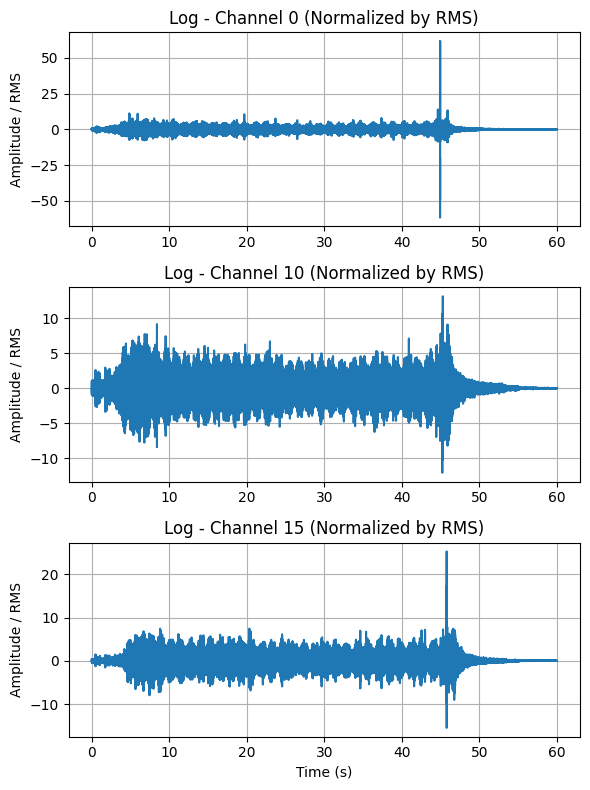

In [6]:
file_path = 'Log.mat'

print(f"📂 파일 로드 시작: {file_path}")

try:
    # ==========================================
    # 2. 내부 변수 이름(Key) 자동 찾기
    # ==========================================
    target_key = None
    raw_data_array = None

    with h5py.File(file_path, 'r') as f:
        keys = list(f.keys())
        valid_keys = [k for k in keys if not k.startswith('#')]
        
        if len(valid_keys) > 0:
            target_key = valid_keys[0]
            print(f"   👉 감지된 내부 데이터 그룹 이름: '{target_key}'")
            
            if 'rawdata' in f[target_key]:
                raw_data_array = f[target_key]['rawdata'][()]
            else:
                raise ValueError(f"'{target_key}' 안에 'rawdata'가 없습니다.")
        else:
            raise ValueError("유효한 데이터 그룹을 찾을 수 없습니다.")

    # ==========================================
    # 3. 데이터 가공 (전치, NaN 제거, RMS 정규화)
    # ==========================================
    raw_data_array = np.asarray(raw_data_array)
    
    # 데이터 형태 확인 및 전치
    if raw_data_array.ndim == 2 and raw_data_array.shape[0] < raw_data_array.shape[1]:
        raw_data_array = raw_data_array.T 

    row_idx = np.arange(0, 16, dtype=int)
    x_normal = [] # 여기에 RMS로 나눈 정규화된 데이터를 담습니다.
    
    print("\n📊 RMS 계산 및 정규화 진행 중...")

    for i in row_idx:
        if i < raw_data_array.shape[1]:
            # 1) 데이터 추출 및 실수 변환
            x = raw_data_array[:, i].astype(float)
            
            # 2) NaN 제거
            x = x[~np.isnan(x)] 
            
            if len(x) > 0:
                # ------------------------------------------------
                # [수정됨] RMS 계산 및 정규화 로직
                # ------------------------------------------------
                # 3) RMS 값 계산 (Root Mean Square)
                rms_val = np.sqrt(np.mean(x**2))
                
                # 4) 정규화 (진폭 / RMS)
                # 0으로 나누기 방지
                if rms_val > 0:
                    x_norm_data = x / rms_val
                else:
                    x_norm_data = x # RMS가 0이면 그대로 (모두 0인 신호)
                
                # 5) 리스트에 추가
                x_normal.append(x_norm_data)
                
                # (선택 사항) 채널별 RMS 값 출력 확인
                # print(f" - Ch {i} RMS: {rms_val:.4f}")
            else:
                # 데이터가 모두 NaN이거나 비어있는 경우 빈 배열 추가
                x_normal.append(np.array([]))

    # ==========================================
    # 4. 결과 출력 및 그래프 (Log용)
    # ==========================================
    if len(x_normal) > 0 and len(x_normal[0]) > 0:
        N = len(x_normal[0])
        t = np.arange(N)/fs
        
        print(f"✅ 데이터 로드 및 RMS 정규화 완료: 총 {len(x_normal)}개 채널")

        # 그래프 그리기 (채널 0, 10, 15)
        plt.figure(figsize=(6, 8))
        
        # Channel 0
        plt.subplot(3, 1, 1)
        plt.plot(t, x_normal[0])
        plt.title(f'Log - Channel 0 (Normalized by RMS)')
        plt.ylabel('Amplitude / RMS')
        plt.grid(True)

        # Channel 10
        if len(x_normal) > 10 and len(x_normal[10]) > 0:
            plt.subplot(3, 1, 2)
            plt.plot(t, x_normal[10])
            plt.title(f'Log - Channel 10 (Normalized by RMS)')
            plt.ylabel('Amplitude / RMS')
            plt.grid(True)

        # Channel 15
        if len(x_normal) > 15 and len(x_normal[15]) > 0:
            plt.subplot(3, 1, 3)
            plt.plot(t, x_normal[15])
            plt.title(f'Log - Channel 15 (Normalized by RMS)')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude / RMS')
            plt.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 시각화할 유효한 데이터가 없습니다.")

except Exception as e:
    print(f"❌ 오류 발생: {e}")

## Log100.mat 

In [7]:
# # 1. 파일 경로 설정 (Log100으로 변경)
# # ==========================================
# file_path = 'Log100.mat'


# print(f"📂 파일 로드 시작: {file_path}")

# try:
#     # ==========================================
#     # 2. 내부 변수 이름(Key) 자동 찾기 (핵심!)
#     # ==========================================
#     # Log100.mat 안의 변수명이 'Log100'일지 'Log'일지 몰라도 알아서 찾습니다.
#     target_key = None
#     raw_data_array = None

#     with h5py.File(file_path, 'r') as f:
#         keys = list(f.keys())
#         # 시스템 변수(#refs# 등)를 제외하고 실제 데이터 그룹 이름 찾기
#         valid_keys = [k for k in keys if not k.startswith('#')]
        
#         if len(valid_keys) > 0:
#             target_key = valid_keys[0] # 가장 유력한 키 선택
#             print(f"   👉 감지된 내부 데이터 그룹 이름: '{target_key}'")
            
#             if 'rawdata' in f[target_key]:
#                 raw_data_array = f[target_key]['rawdata'][()]
#             else:
#                 raise ValueError(f"'{target_key}' 안에 'rawdata'가 없습니다.")
#         else:
#             raise ValueError("유효한 데이터 그룹을 찾을 수 없습니다.")

#     # ==========================================
#     # 3. 데이터 가공 (전치 및 NaN 제거)
#     # ==========================================
#     raw_data_array = np.asarray(raw_data_array)
    
#     # 데이터 형태 확인 및 전치(Transpose)
#     if raw_data_array.ndim == 2 and raw_data_array.shape[0] < raw_data_array.shape[1]:
#         raw_data_array = raw_data_array.T 

#     row_idx = np.arange(0, 16, dtype=int)
#     x_normal = []
    
#     for i in row_idx:
#         if i < raw_data_array.shape[1]:
#             x = raw_data_array[:, i].astype(float)
#             x = x[~np.isnan(x)] # NaN 제거
#             x_normal.append(x)

#     # ==========================================
#     # 4. 결과 출력 및 그래프 (Log100용)
#     # ==========================================
#     if len(x_normal) > 0:
#         N = len(x_normal[0])
#         t = np.arange(N)/fs
        
#         print(f"✅ 데이터 로드 완료: 총 {len(x_normal)}개 채널, 길이 {N}")

#         # 그래프 그리기 (채널 0, 10, 15)
#         plt.figure(figsize=(6, 8))
        
#         # Channel 0
#         plt.subplot(3, 1, 1)
#         plt.plot(t, x_normal[0])
#         plt.title('Log100 - Channel 0')
#         plt.ylabel('Amplitude')
#         plt.grid(True)

#         # Channel 10
#         if len(x_normal) > 10:
#             plt.subplot(3, 1, 2)
#             plt.plot(t, x_normal[10])
#             plt.title('Log100 - Channel 10')
#             plt.ylabel('Amplitude')
#             plt.grid(True)

#         # Channel 15
#         if len(x_normal) > 15:
#             plt.subplot(3, 1, 3)
#             plt.plot(t, x_normal[15])
#             plt.title('Log100 - Channel 15')
#             plt.xlabel('Time (s)')
#             plt.ylabel('Amplitude')
#             plt.grid(True)

#         plt.tight_layout()
#         plt.show()

# except Exception as e:
#     print(f"❌ 오류 발생: {e}")

## Log100.mat  => 진폭 / rms

📂 파일 로드 시작: Log100.mat
   👉 감지된 내부 데이터 그룹 이름: 'Log100'

📊 RMS 계산 및 정규화 진행 중...
✅ 데이터 로드 및 RMS 정규화 완료: 총 16개 채널


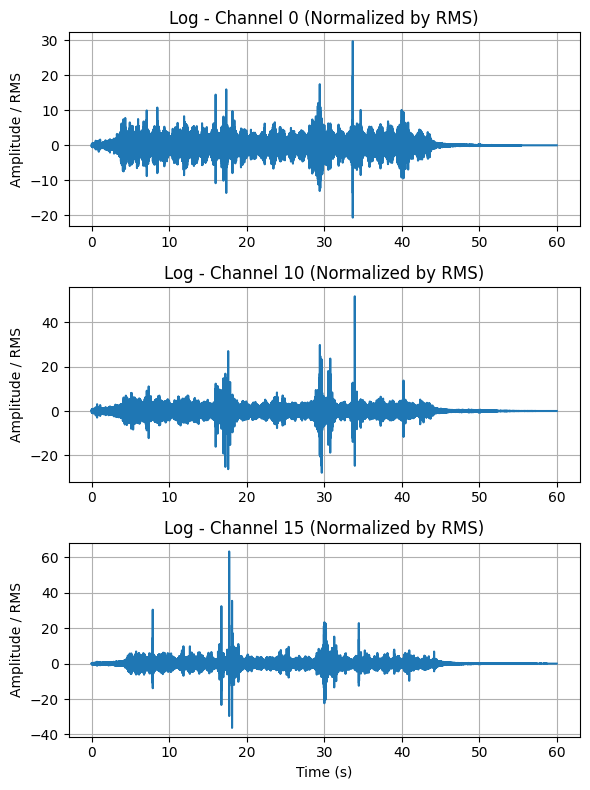

In [8]:
file_path = 'Log100.mat'

print(f"📂 파일 로드 시작: {file_path}")

try:
    # ==========================================
    # 2. 내부 변수 이름(Key) 자동 찾기
    # ==========================================
    target_key = None
    raw_data_array = None

    with h5py.File(file_path, 'r') as f:
        keys = list(f.keys())
        valid_keys = [k for k in keys if not k.startswith('#')]
        
        if len(valid_keys) > 0:
            target_key = valid_keys[0]
            print(f"   👉 감지된 내부 데이터 그룹 이름: '{target_key}'")
            
            if 'rawdata' in f[target_key]:
                raw_data_array = f[target_key]['rawdata'][()]
            else:
                raise ValueError(f"'{target_key}' 안에 'rawdata'가 없습니다.")
        else:
            raise ValueError("유효한 데이터 그룹을 찾을 수 없습니다.")

    # ==========================================
    # 3. 데이터 가공 (전치, NaN 제거, RMS 정규화)
    # ==========================================
    raw_data_array = np.asarray(raw_data_array)
    
    # 데이터 형태 확인 및 전치
    if raw_data_array.ndim == 2 and raw_data_array.shape[0] < raw_data_array.shape[1]:
        raw_data_array = raw_data_array.T 

    row_idx = np.arange(0, 16, dtype=int)
    x_normal_100 = [] # 여기에 RMS로 나눈 정규화된 데이터를 담습니다.
    
    print("\n📊 RMS 계산 및 정규화 진행 중...")

    for i in row_idx:
        if i < raw_data_array.shape[1]:
            # 1) 데이터 추출 및 실수 변환
            x = raw_data_array[:, i].astype(float)
            
            # 2) NaN 제거
            x = x[~np.isnan(x)] 
            
            if len(x) > 0:
                # ------------------------------------------------
                # [수정됨] RMS 계산 및 정규화 로직
                # ------------------------------------------------
                # 3) RMS 값 계산 (Root Mean Square)
                rms_val = np.sqrt(np.mean(x**2))
                
                # 4) 정규화 (진폭 / RMS)
                # 0으로 나누기 방지
                if rms_val > 0:
                    x_norm_data = x / rms_val
                else:
                    x_norm_data = x # RMS가 0이면 그대로 (모두 0인 신호)
                
                # 5) 리스트에 추가
                x_normal_100.append(x_norm_data)
                
                # (선택 사항) 채널별 RMS 값 출력 확인
                # print(f" - Ch {i} RMS: {rms_val:.4f}")
            else:
                # 데이터가 모두 NaN이거나 비어있는 경우 빈 배열 추가
                x_normal_100.append(np.array([]))

    # ==========================================
    # 4. 결과 출력 및 그래프 (Log용)
    # ==========================================
    if len(x_normal_100) > 0 and len(x_normal_100[0]) > 0:
        N = len(x_normal_100[0])
        t = np.arange(N)/fs
        
        print(f"✅ 데이터 로드 및 RMS 정규화 완료: 총 {len(x_normal_100)}개 채널")

        # 그래프 그리기 (채널 0, 10, 15)
        plt.figure(figsize=(6, 8))
        
        # Channel 0
        plt.subplot(3, 1, 1)
        plt.plot(t, x_normal_100[0])
        plt.title(f'Log - Channel 0 (Normalized by RMS)')
        plt.ylabel('Amplitude / RMS')
        plt.grid(True)

        # Channel 10
        if len(x_normal_100) > 10 and len(x_normal_100[10]) > 0:
            plt.subplot(3, 1, 2)
            plt.plot(t, x_normal_100[10])
            plt.title(f'Log - Channel 10 (Normalized by RMS)')
            plt.ylabel('Amplitude / RMS')
            plt.grid(True)

        # Channel 15
        if len(x_normal_100) > 15 and len(x_normal_100[15]) > 0:
            plt.subplot(3, 1, 3)
            plt.plot(t, x_normal_100[15])
            plt.title(f'Log - Channel 15 (Normalized by RMS)')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude / RMS')
            plt.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 시각화할 유효한 데이터가 없습니다.")

except Exception as e:
    print(f"❌ 오류 발생: {e}")

## Log107.mat 

In [9]:
# # 1. 파일 경로 설정 (Log107으로 변경)
# # ==========================================
# file_path = 'Log107.mat'


# print(f"📂 파일 로드 시작: {file_path}")

# try:
#     # ==========================================
#     # 2. 내부 변수 이름(Key) 자동 찾기 (핵심!)
#     # ==========================================
#     # Log107.mat 안의 변수명이 'Log107'일지 'Log'일지 몰라도 알아서 찾습니다.
#     target_key = None
#     raw_data_array = None

#     with h5py.File(file_path, 'r') as f:
#         keys = list(f.keys())
#         # 시스템 변수(#refs# 등)를 제외하고 실제 데이터 그룹 이름 찾기
#         valid_keys = [k for k in keys if not k.startswith('#')]
        
#         if len(valid_keys) > 0:
#             target_key = valid_keys[0] # 가장 유력한 키 선택
#             print(f"   👉 감지된 내부 데이터 그룹 이름: '{target_key}'")
            
#             if 'rawdata' in f[target_key]:
#                 raw_data_array = f[target_key]['rawdata'][()]
#             else:
#                 raise ValueError(f"'{target_key}' 안에 'rawdata'가 없습니다.")
#         else:
#             raise ValueError("유효한 데이터 그룹을 찾을 수 없습니다.")

#     # ==========================================
#     # 3. 데이터 가공 (전치 및 NaN 제거)
#     # ==========================================
#     raw_data_array = np.asarray(raw_data_array)
    
#     # 데이터 형태 확인 및 전치(Transpose)
#     if raw_data_array.ndim == 2 and raw_data_array.shape[0] < raw_data_array.shape[1]:
#         raw_data_array = raw_data_array.T 

#     row_idx = np.arange(0, 16, dtype=int)
#     x_normal = []
    
#     for i in row_idx:
#         if i < raw_data_array.shape[1]:
#             x = raw_data_array[:, i].astype(float)
#             x = x[~np.isnan(x)] # NaN 제거
#             x_normal.append(x)

#     # ==========================================
#     # 4. 결과 출력 및 그래프 (Log107용)
#     # ==========================================
#     if len(x_normal) > 0:
#         N = len(x_normal[0])
#         t = np.arange(N)/fs
        
#         print(f"✅ 데이터 로드 완료: 총 {len(x_normal)}개 채널, 길이 {N}")

#         # 그래프 그리기 (채널 0, 10, 15)
#         plt.figure(figsize=(6, 8))
        
#         # Channel 0
#         plt.subplot(3, 1, 1)
#         plt.plot(t, x_normal[0])
#         plt.title('Log107 - Channel 0')
#         plt.ylabel('Amplitude')
#         plt.grid(True)

#         # Channel 10
#         if len(x_normal) > 10:
#             plt.subplot(3, 1, 2)
#             plt.plot(t, x_normal[10])
#             plt.title('Log107 - Channel 10')
#             plt.ylabel('Amplitude')
#             plt.grid(True)

#         # Channel 15
#         if len(x_normal) > 15:
#             plt.subplot(3, 1, 3)
#             plt.plot(t, x_normal[15])
#             plt.title('Log107 - Channel 15')
#             plt.xlabel('Time (s)')
#             plt.ylabel('Amplitude')
#             plt.grid(True)

#         plt.tight_layout()
#         plt.show()

# except Exception as e:
#     print(f"❌ 오류 발생: {e}")

## Log107.mat  => 진폭 / rms

📂 파일 로드 시작: Log107.mat
   👉 감지된 내부 데이터 그룹 이름: 'Log107'

📊 RMS 계산 및 정규화 진행 중...
✅ 데이터 로드 및 RMS 정규화 완료: 총 16개 채널


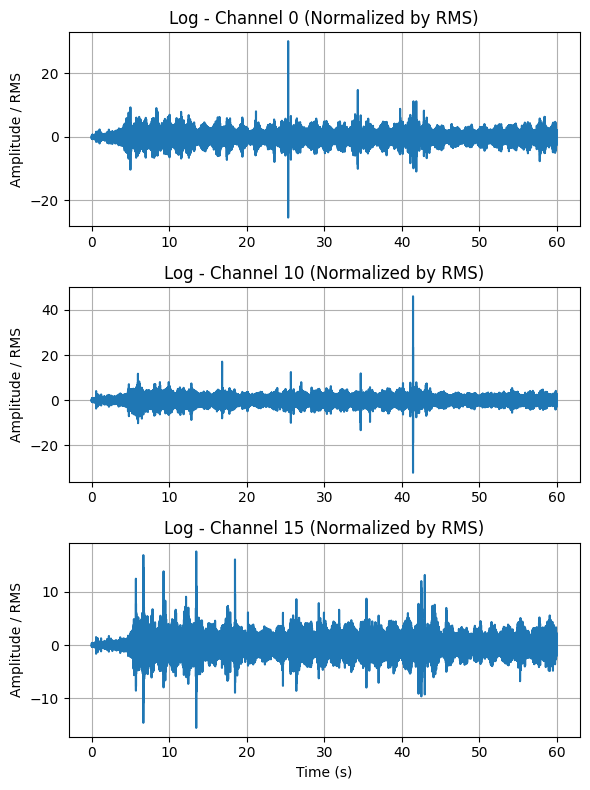

In [10]:
file_path = 'Log107.mat'

print(f"📂 파일 로드 시작: {file_path}")

try:
    # ==========================================
    # 2. 내부 변수 이름(Key) 자동 찾기
    # ==========================================
    target_key = None
    raw_data_array = None

    with h5py.File(file_path, 'r') as f:
        keys = list(f.keys())
        valid_keys = [k for k in keys if not k.startswith('#')]
        
        if len(valid_keys) > 0:
            target_key = valid_keys[0]
            print(f"   👉 감지된 내부 데이터 그룹 이름: '{target_key}'")
            
            if 'rawdata' in f[target_key]:
                raw_data_array = f[target_key]['rawdata'][()]
            else:
                raise ValueError(f"'{target_key}' 안에 'rawdata'가 없습니다.")
        else:
            raise ValueError("유효한 데이터 그룹을 찾을 수 없습니다.")

    # ==========================================
    # 3. 데이터 가공 (전치, NaN 제거, RMS 정규화)
    # ==========================================
    raw_data_array = np.asarray(raw_data_array)
    
    # 데이터 형태 확인 및 전치
    if raw_data_array.ndim == 2 and raw_data_array.shape[0] < raw_data_array.shape[1]:
        raw_data_array = raw_data_array.T 

    row_idx = np.arange(0, 16, dtype=int)
    x_normal_107 = [] # 여기에 RMS로 나눈 정규화된 데이터를 담습니다.
    
    print("\n📊 RMS 계산 및 정규화 진행 중...")

    for i in row_idx:
        if i < raw_data_array.shape[1]:
            # 1) 데이터 추출 및 실수 변환
            x = raw_data_array[:, i].astype(float)
            
            # 2) NaN 제거
            x = x[~np.isnan(x)] 
            
            if len(x) > 0:
                # ------------------------------------------------
                # [수정됨] RMS 계산 및 정규화 로직
                # ------------------------------------------------
                # 3) RMS 값 계산 (Root Mean Square)
                rms_val = np.sqrt(np.mean(x**2))
                
                # 4) 정규화 (진폭 / RMS)
                # 0으로 나누기 방지
                if rms_val > 0:
                    x_norm_data = x / rms_val
                else:
                    x_norm_data = x # RMS가 0이면 그대로 (모두 0인 신호)
                
                # 5) 리스트에 추가
                x_normal_107.append(x_norm_data)
                
                # (선택 사항) 채널별 RMS 값 출력 확인
                # print(f" - Ch {i} RMS: {rms_val:.4f}")
            else:
                # 데이터가 모두 NaN이거나 비어있는 경우 빈 배열 추가
                x_normal_107.append(np.array([]))

    # ==========================================
    # 4. 결과 출력 및 그래프 (Log용)
    # ==========================================
    if len(x_normal_107) > 0 and len(x_normal_107[0]) > 0:
        N = len(x_normal_107[0])
        t = np.arange(N)/fs
        
        print(f"✅ 데이터 로드 및 RMS 정규화 완료: 총 {len(x_normal_107)}개 채널")

        # 그래프 그리기 (채널 0, 10, 15)
        plt.figure(figsize=(6, 8))
        
        # Channel 0
        plt.subplot(3, 1, 1)
        plt.plot(t, x_normal_107[0])
        plt.title(f'Log - Channel 0 (Normalized by RMS)')
        plt.ylabel('Amplitude / RMS')
        plt.grid(True)

        # Channel 10
        if len(x_normal_107) > 10 and len(x_normal_107[10]) > 0:
            plt.subplot(3, 1, 2)
            plt.plot(t, x_normal_107[10])
            plt.title(f'Log - Channel 10 (Normalized by RMS)')
            plt.ylabel('Amplitude / RMS')
            plt.grid(True)

        # Channel 15
        if len(x_normal_107) > 15 and len(x_normal_107[15]) > 0:
            plt.subplot(3, 1, 3)
            plt.plot(t, x_normal_107[15])
            plt.title(f'Log - Channel 15 (Normalized by RMS)')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude / RMS')
            plt.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 시각화할 유효한 데이터가 없습니다.")

except Exception as e:
    print(f"❌ 오류 발생: {e}")

In [11]:
# Fault Characteristic Frequency
rng = np.random.default_rng(0)
fault_freq, FTF, FCF, unit = get_fault_frequency(config)
fr = config['speed_rpm']/60
print(f'Rotational frequency: {fr:.1f} Hz')
print(f'freq_w_fault_featurey: {fault_freq:.1f} Hz')
# Unit impulse response
unit_fault_feature, Beta, Fn = generate_unit_impulse_response(t, config['beta_range'], config['fn_range'], rng)     
# Synthesized Faulty Signal
x_fault_feature = fault_repeat_uncertainty(unit_fault_feature, FCF, fr, t, fs, FTF, config['condition']) * config['fault_amp']





Rotational frequency: 22.5 Hz
freq_w_fault_featurey: 110.4 Hz


임계값 10 기준으로 클리핑을 시작합니다...
총 131개의 샘플이 0으로 처리되었습니다.
원본 신호와 클리핑 제거 신호를 비교합니다.


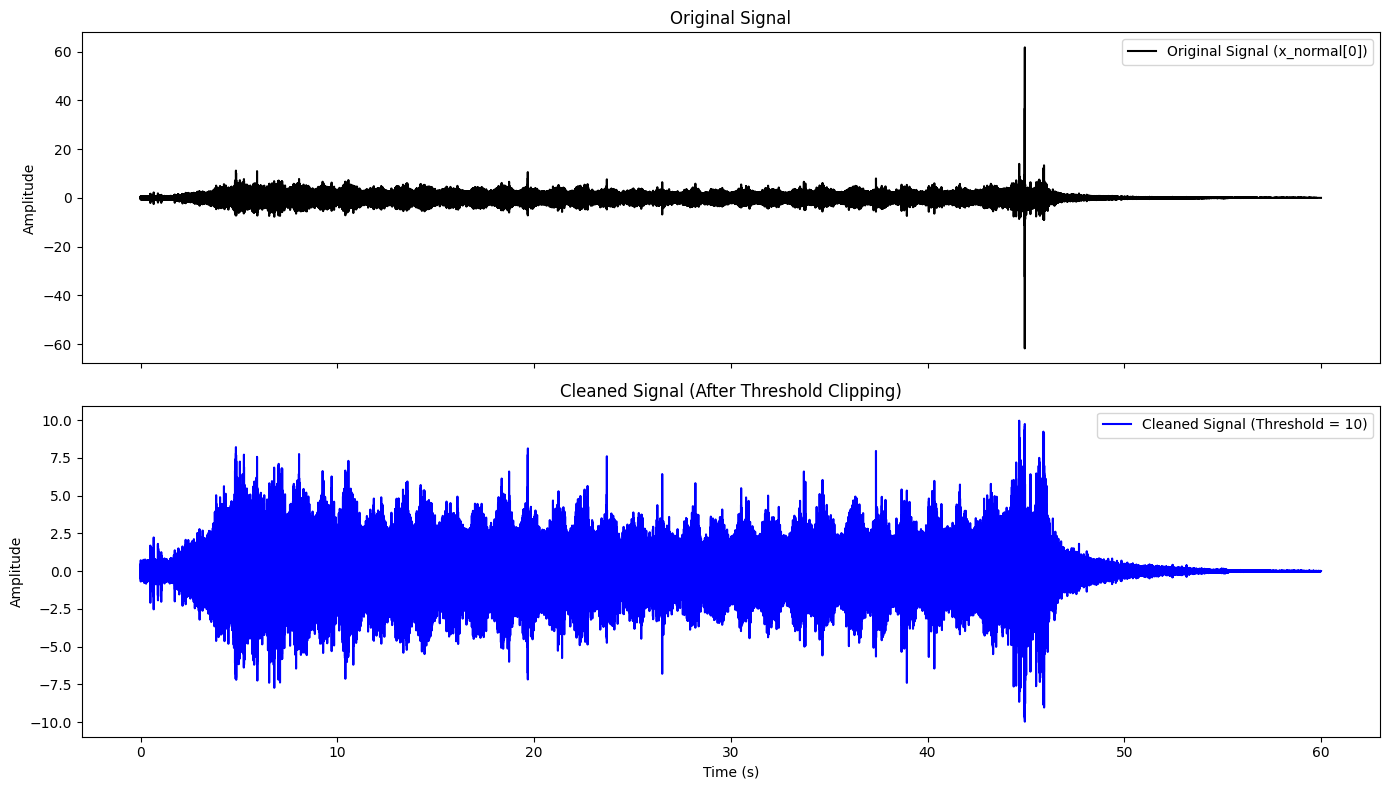

In [18]:
  
try:
    # x_normal[0]이 (Error 2에서 확인된) ndarray라고 가정합니다.
    data_0_0 = x_normal[0]
    
    # [⚠️ 사용자 수정 필요 1]
    fs = config['fs'] # 실제 샘플링 주파수
    
    # [⚠️ 사용자 수정 필요 2]
    threshold = 10  # 스파이크 제거 임계값 (조절 가능)

    # --- 2. 시간 축(t) 생성 ---
    total_samples_0_0 = len(data_0_0)
    total_time_sec_0_0 = total_samples_0_0 / fs
    t = np.linspace(0, total_time_sec_0_0, total_samples_0_0, endpoint=False)
    
    # --- 3. 클리핑(Clipping) 실행 ---
    print(f"임계값 {threshold} 기준으로 클리핑을 시작합니다...")
    
    # 'data'가 ndarray이므로 .copy()와 np.abs()가 정상 작동해야 합니다.
    cleaned_signal_0_0 = data_0_0.copy()
    spike_indices_0_0 = np.abs(data_0_0) > threshold
    cleaned_signal_0_0[spike_indices_0_0] = 0
    
    print(f"총 {np.sum(spike_indices_0_0)}개의 샘플이 0으로 처리되었습니다.")
    
    # --- 4. 원본과 클리핑된 신호 비교 시각화 ---
    print("원본 신호와 클리핑 제거 신호를 비교합니다.")
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # 4-1. 원본 신호
    axes[0].plot(t, data_0_0, 'k', label="Original Signal (x_normal[0])")
    axes[0].set_title("Original Signal")
    axes[0].legend()
    axes[0].set_ylabel("Amplitude")
    
    # 4-2. 클리핑된 신호
    axes[1].plot(t, cleaned_signal_0_0, 'b', label=f"Cleaned Signal (Threshold = {threshold})")
    axes[1].set_title("Cleaned Signal (After Threshold Clipping)")
    axes[1].legend()
    axes[1].set_ylabel("Amplitude")
    
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

except NameError as e:
    if 'x_normal' in str(e):
        print("---!!! 오류 !!!---")
        print("커널 재시작 후, 'x_normal' 변수를 로드하는 셀을 먼저 실행해주세요.")
    else:
        print(f"오류 발생: {e}")
except TypeError as e:
    print("---!!! 타입 오류 발생 !!!---")
    print(f"오류: {e}")
    print(f"'data' 변수의 타입이 {type(data_0_0)}입니다.")
    print("만약 'data'가 딕셔너리(dict)라면, data = x_normal[0]['실제_키'] 처럼 수정해야 합니다.")

임계값 10 기준으로 클리핑을 시작합니다...
총 145개의 샘플이 0으로 처리되었습니다.
원본 신호와 클리핑 제거 신호를 비교합니다.


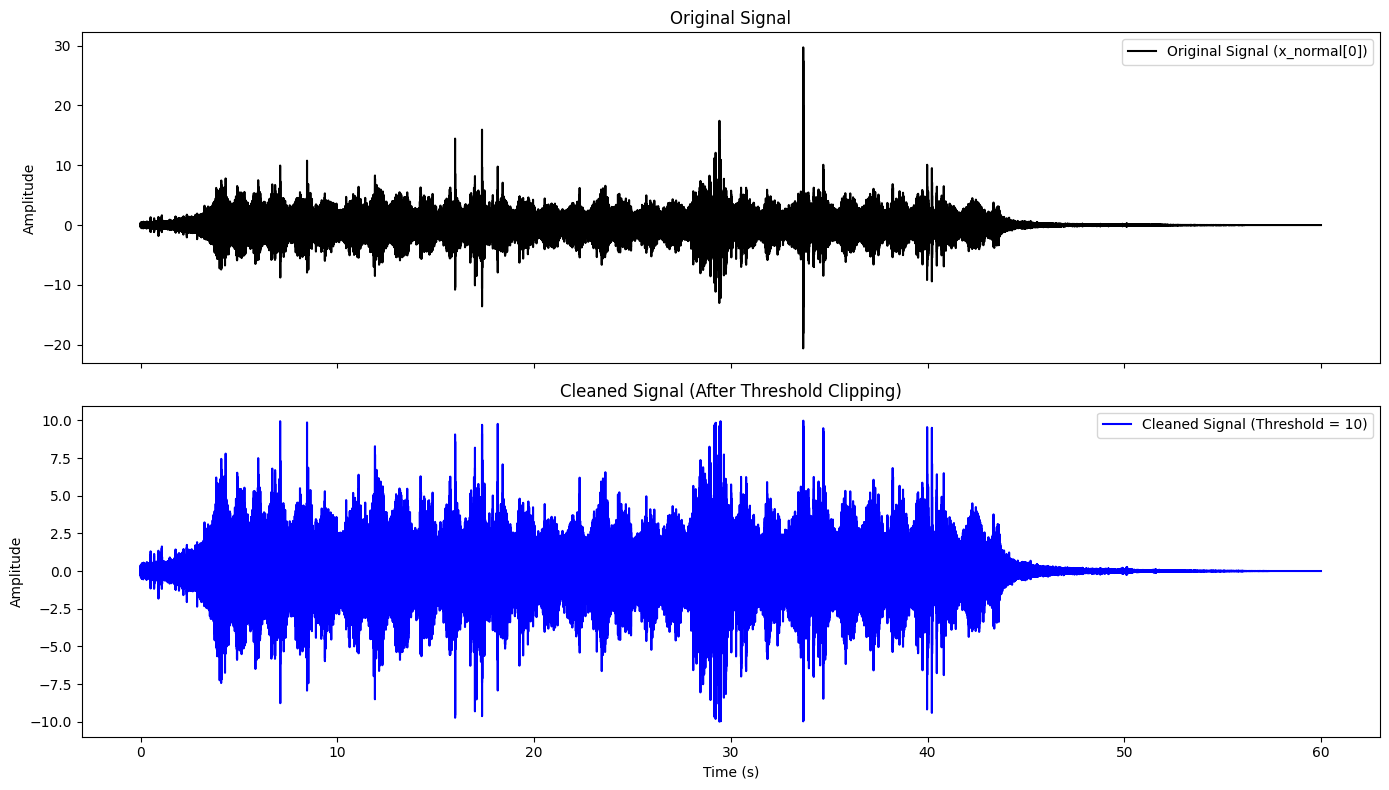

In [19]:
  
try:
    # x_normal[0]이 (Error 2에서 확인된) ndarray라고 가정합니다.
    data_100_0 = x_normal_100[0] 
    
    # [⚠️ 사용자 수정 필요 1]
    fs = config['fs'] # 실제 샘플링 주파수
    
    # [⚠️ 사용자 수정 필요 2]
    threshold = 10  # 스파이크 제거 임계값 (조절 가능)

    # --- 2. 시간 축(t) 생성 ---
    total_samples_100_0 = len(data_100_0)
    total_time_sec_100_0 = total_samples_100_0 / fs
    t = np.linspace(0, total_time_sec_100_0, total_samples_100_0, endpoint=False)
    
    # --- 3. 클리핑(Clipping) 실행 ---
    print(f"임계값 {threshold} 기준으로 클리핑을 시작합니다...")
    
    # 'data'가 ndarray이므로 .copy()와 np.abs()가 정상 작동해야 합니다.
    cleaned_signal_100_0 = data_100_0.copy()
    spike_indices_100_0 = np.abs(data_100_0) > threshold
    cleaned_signal_100_0[spike_indices_100_0] = 0
    
    print(f"총 {np.sum(spike_indices_100_0)}개의 샘플이 0으로 처리되었습니다.")
    
    # --- 4. 원본과 클리핑된 신호 비교 시각화 ---
    print("원본 신호와 클리핑 제거 신호를 비교합니다.")
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # 4-1. 원본 신호
    axes[0].plot(t, data_100_0, 'k', label="Original Signal (x_normal[0])")
    axes[0].set_title("Original Signal")
    axes[0].legend()
    axes[0].set_ylabel("Amplitude")
    
    # 4-2. 클리핑된 신호
    axes[1].plot(t, cleaned_signal_100_0, 'b', label=f"Cleaned Signal (Threshold = {threshold})")
    axes[1].set_title("Cleaned Signal (After Threshold Clipping)")
    axes[1].legend()
    axes[1].set_ylabel("Amplitude")
    
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

except NameError as e:
    if 'x_normal' in str(e):
        print("---!!! 오류 !!!---")
        print("커널 재시작 후, 'x_normal' 변수를 로드하는 셀을 먼저 실행해주세요.")
    else:
        print(f"오류 발생: {e}")
except TypeError as e:
    print("---!!! 타입 오류 발생 !!!---")
    print(f"오류: {e}")
    print(f"'data' 변수의 타입이 {type(data_100_0)}입니다.")
    print("만약 'data'가 딕셔너리(dict)라면, data = x_normal[0]['실제_키'] 처럼 수정해야 합니다.")

임계값 10 기준으로 클리핑을 시작합니다...
총 66개의 샘플이 0으로 처리되었습니다.
원본 신호와 클리핑 제거 신호를 비교합니다.


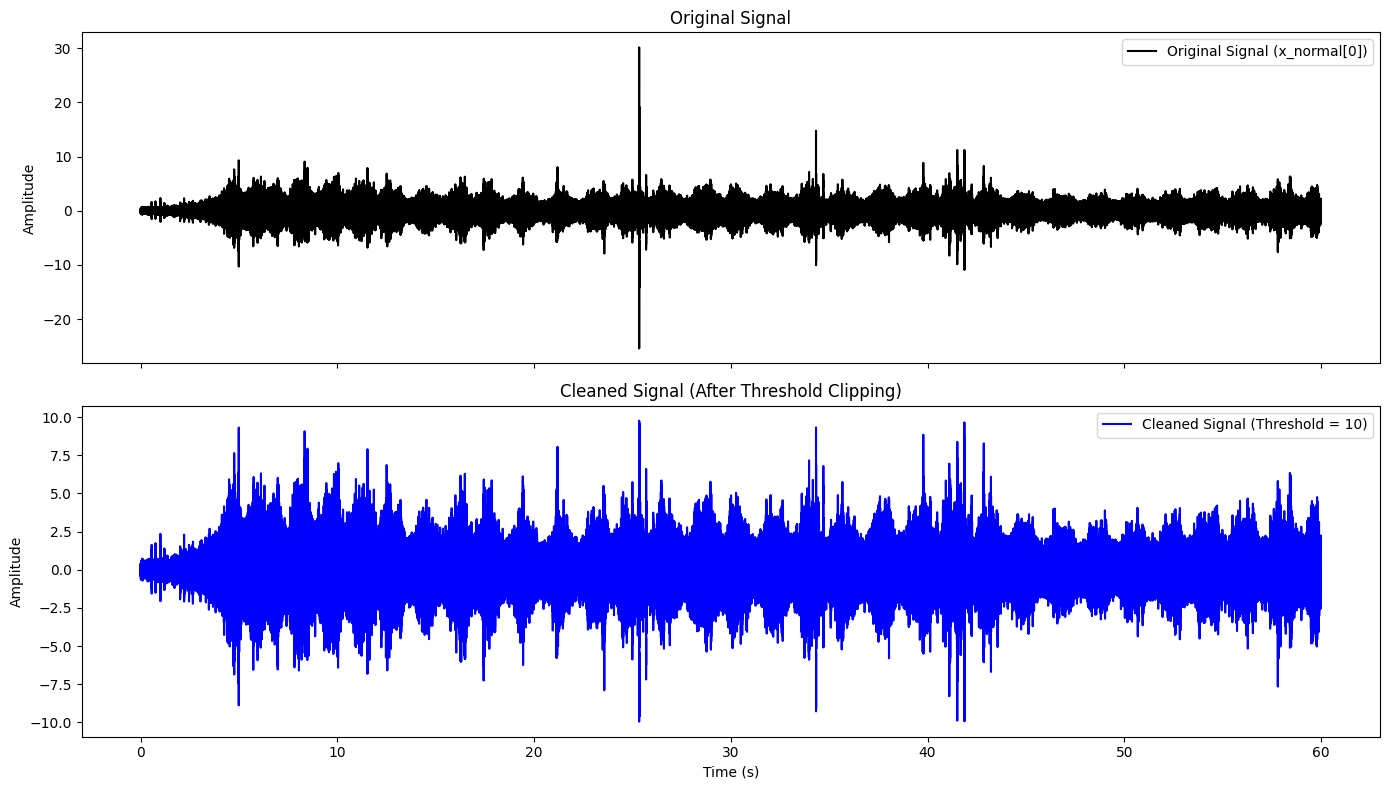

In [20]:
  
try:
    # x_normal[0]이 (Error 2에서 확인된) ndarray라고 가정합니다.
    data_107_0 = x_normal_107[0]
    
    # [⚠️ 사용자 수정 필요 1]
    fs = config['fs'] # 실제 샘플링 주파수
    
    # [⚠️ 사용자 수정 필요 2]
    threshold = 10  # 스파이크 제거 임계값 (조절 가능)

    # --- 2. 시간 축(t) 생성 ---
    total_samples_107_0 = len(data_107_0)
    total_time_sec_107_0 = total_samples_107_0 / fs
    t = np.linspace(0, total_time_sec_107_0, total_samples_107_0, endpoint=False)
    
    # --- 3. 클리핑(Clipping) 실행 ---
    print(f"임계값 {threshold} 기준으로 클리핑을 시작합니다...")
    
    # 'data'가 ndarray이므로 .copy()와 np.abs()가 정상 작동해야 합니다.
    cleaned_signal_107_0 = data_107_0.copy()
    spike_indices_107_0 = np.abs(data_107_0) > threshold
    cleaned_signal_107_0[spike_indices_107_0] = 0
    
    print(f"총 {np.sum(spike_indices_107_0)}개의 샘플이 0으로 처리되었습니다.")
    
    # --- 4. 원본과 클리핑된 신호 비교 시각화 ---
    print("원본 신호와 클리핑 제거 신호를 비교합니다.")
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # 4-1. 원본 신호
    axes[0].plot(t, data_107_0, 'k', label="Original Signal (x_normal[0])")
    axes[0].set_title("Original Signal")
    axes[0].legend()
    axes[0].set_ylabel("Amplitude")
    
    # 4-2. 클리핑된 신호
    axes[1].plot(t, cleaned_signal_107_0, 'b', label=f"Cleaned Signal (Threshold = {threshold})")
    axes[1].set_title("Cleaned Signal (After Threshold Clipping)")
    axes[1].legend()
    axes[1].set_ylabel("Amplitude")
    
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

except NameError as e:
    if 'x_normal' in str(e):
        print("---!!! 오류 !!!---")
        print("커널 재시작 후, 'x_normal' 변수를 로드하는 셀을 먼저 실행해주세요.")
    else:
        print(f"오류 발생: {e}")
except TypeError as e:
    print("---!!! 타입 오류 발생 !!!---")
    print(f"오류: {e}")
    print(f"'data' 변수의 타입이 {type(data_107_0)}입니다.")
    print("만약 'data'가 딕셔너리(dict)라면, data = x_normal[0]['실제_키'] 처럼 수정해야 합니다.")

In [22]:
x_fault_signal_0 = cleaned_signal_0_0 + x_fault_feature


x_fault_signal_100_0 = cleaned_signal_100_0 + x_fault_feature


x_fault_signal_107_0 = cleaned_signal_107_0 + x_fault_feature


In [23]:
nlevel = config['nlevel']
Kwav_norm, Level_w_norm, freq_w_norm, c_norm, maxK_norm, bw_norm, lvl_norm, Wn_norm = kg.fast_kurtogram(cleaned_signal_0_0, fs, nlevel=nlevel)
Kwav_fault_feature, Level_w_fault_feature, freq_w_fault_feature, c_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, Wn_fault_feature = kg.fast_kurtogram(x_fault_feature, fs, nlevel=nlevel)
Kwav_fault_signal, Level_w_fault_signal, freq_w_fault_signal, c_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, Wn_fault_signal = kg.fast_kurtogram(x_fault_signal_0, fs, nlevel=nlevel)
f_e_n, A_e_n, env_n, xf_n = envelope_spectrum_band(cleaned_signal_0_0, fs, Wn_norm)
f_e_f, A_e_f, env_f, xf_f = envelope_spectrum_band(x_fault_feature, fs, Wn_fault_feature)
f_e_s, A_e_s, env_s, xf_s = envelope_spectrum_band(x_fault_signal_0, fs, Wn_fault_signal)

In [24]:
nlevel = config['nlevel']
Kwav_norm_100, Level_w_norm_100, freq_w_norm_100, c_norm_100, maxK_norm_100, bw_norm_100, lvl_norm_100, Wn_norm_100 = kg.fast_kurtogram(cleaned_signal_100_0, fs, nlevel=nlevel)
Kwav_fault_feature, Level_w_fault_feature, freq_w_fault_feature, c_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, Wn_fault_feature = kg.fast_kurtogram(x_fault_feature, fs, nlevel=nlevel)
Kwav_fault_signal_100, Level_w_fault_signal_100, freq_w_fault_signal_100, c_fault_signal_100, maxK_fault_signal_100, bw_fault_signal_100, lvl_fault_signal_100, Wn_fault_signal_100 = kg.fast_kurtogram(x_fault_signal_100_0, fs, nlevel=nlevel)
f_e_n_100, A_e_n_100, env_n_100, xf_n_100 = envelope_spectrum_band(cleaned_signal_100_0, fs, Wn_norm_100)
f_e_f, A_e_f, env_f, xf_f = envelope_spectrum_band(x_fault_feature, fs, Wn_fault_feature)
f_e_s_100, A_e_s_100, env_s_100, xf_s_100 = envelope_spectrum_band(x_fault_signal_100_0, fs, Wn_fault_signal_100)

In [25]:
nlevel = config['nlevel']
Kwav_norm_107, Level_w_norm_107, freq_w_norm_107, c_norm_107, maxK_norm_107, bw_norm_107, lvl_norm_107, Wn_norm_107 = kg.fast_kurtogram(cleaned_signal_107_0, fs, nlevel=nlevel)
Kwav_fault_feature, Level_w_fault_feature, freq_w_fault_feature, c_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, Wn_fault_feature = kg.fast_kurtogram(x_fault_feature, fs, nlevel=nlevel)
Kwav_fault_signal_107, Level_w_fault_signal_107, freq_w_fault_signal_107, c_fault_signal_107, maxK_fault_signal_107, bw_fault_signal_107, lvl_fault_signal_107, Wn_fault_signal_107 = kg.fast_kurtogram(x_fault_signal_107_0, fs, nlevel=nlevel)
f_e_n_107, A_e_n_107, env_n_107, xf_n_107 = envelope_spectrum_band(cleaned_signal_107_0, fs, Wn_norm_107)
f_e_f, A_e_f, env_f, xf_f = envelope_spectrum_band(x_fault_feature, fs, Wn_fault_feature)
f_e_s_107, A_e_s_107, env_s_107, xf_s_107 = envelope_spectrum_band(x_fault_signal_107_0, fs, Wn_fault_signal_107)

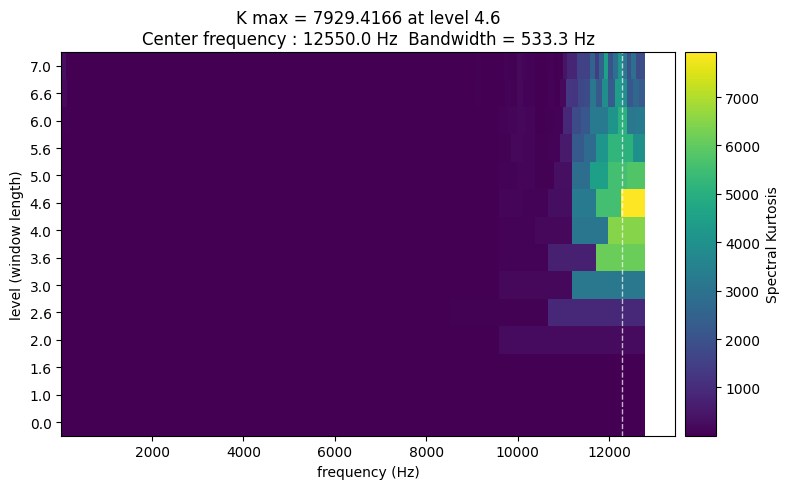

[12283.33333333 12799.        ]


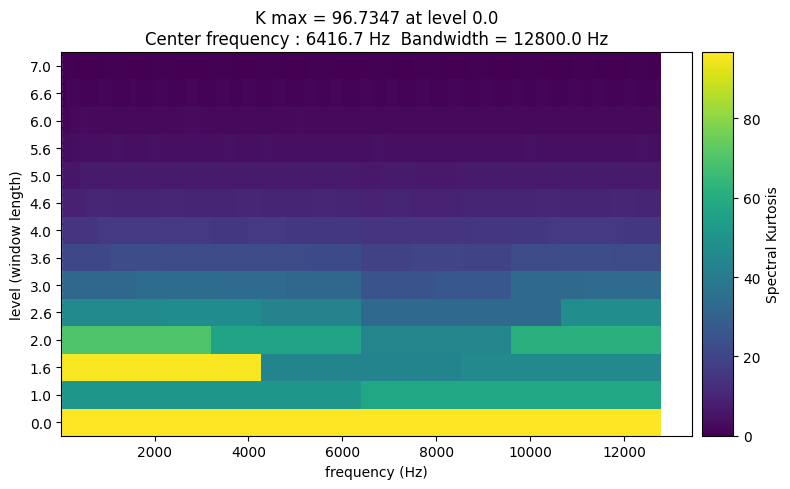

[   16.66666667 12799.        ]


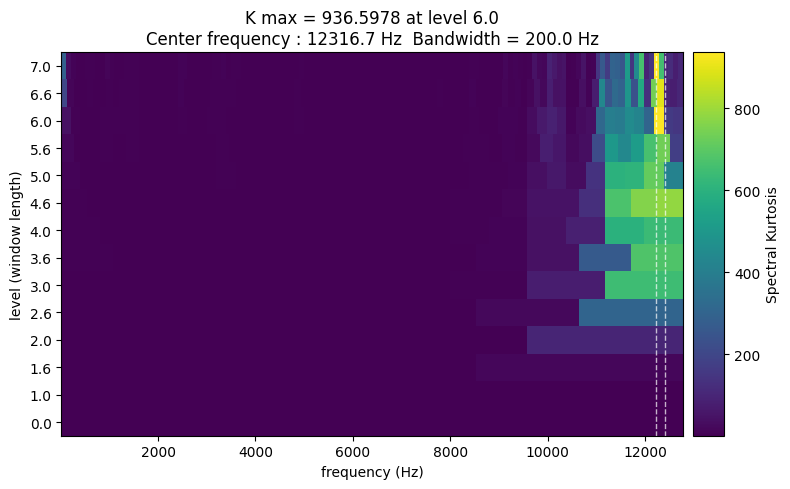

[12216.66666667 12416.66666667]


In [26]:
# 1. 커토그램 계산 (nlevel 인자는 여기에 사용합니다)
kg.plot_kurtogram(Kwav_norm, Level_w_norm, maxK_norm, bw_norm, lvl_norm, fs, Wn_norm)
print(Wn_norm)
kg.plot_kurtogram(Kwav_fault_feature, Level_w_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, fs, Wn_fault_feature)
print(Wn_fault_feature)
kg.plot_kurtogram(Kwav_fault_signal, Level_w_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, fs, Wn_fault_signal)
print(Wn_fault_signal)

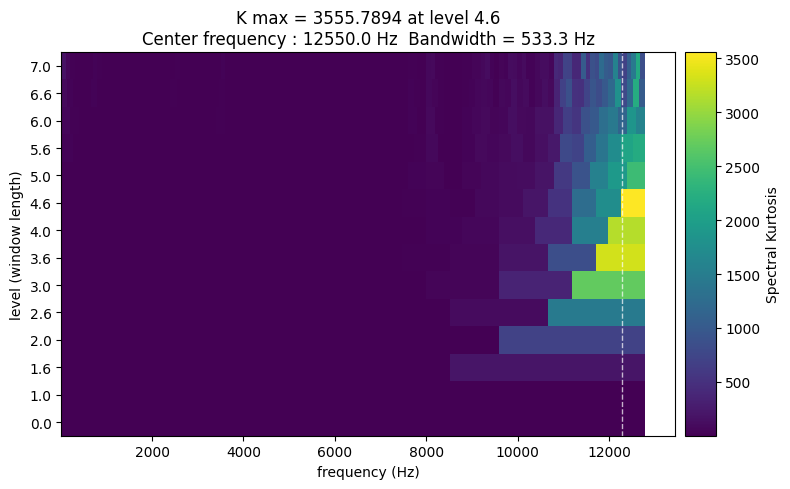

[12283.33333333 12799.        ]


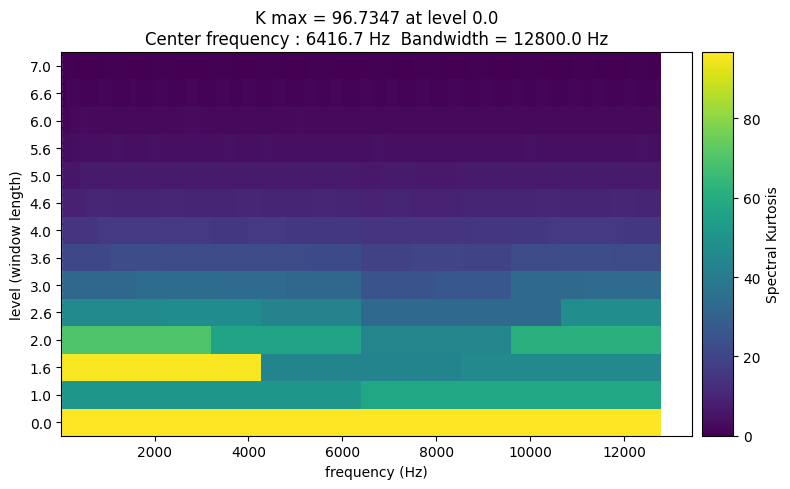

[   16.66666667 12799.        ]


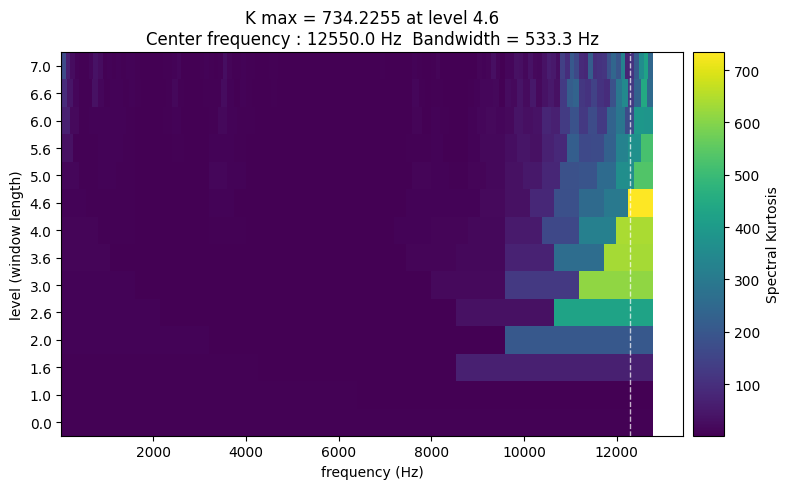

[12283.33333333 12799.        ]


In [27]:
# 1. 커토그램 계산 (nlevel 인자는 여기에 사용합니다)
kg.plot_kurtogram(Kwav_norm_100, Level_w_norm_100, maxK_norm_100, bw_norm_100, lvl_norm_100, fs, Wn_norm_100)
print(Wn_norm_100)
kg.plot_kurtogram(Kwav_fault_feature, Level_w_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, fs, Wn_fault_feature)
print(Wn_fault_feature)
kg.plot_kurtogram(Kwav_fault_signal_100, Level_w_fault_signal_100, maxK_fault_signal_100, bw_fault_signal_100, lvl_fault_signal_100, fs, Wn_fault_signal_100)
print(Wn_fault_signal_100)

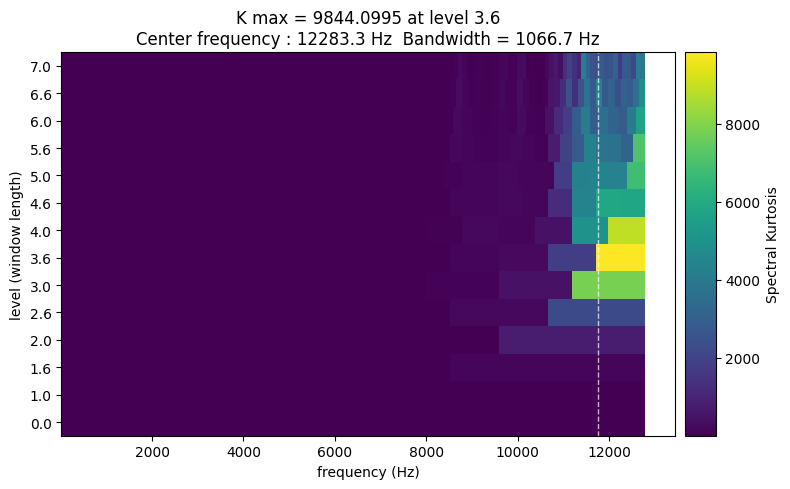

[11750. 12799.]


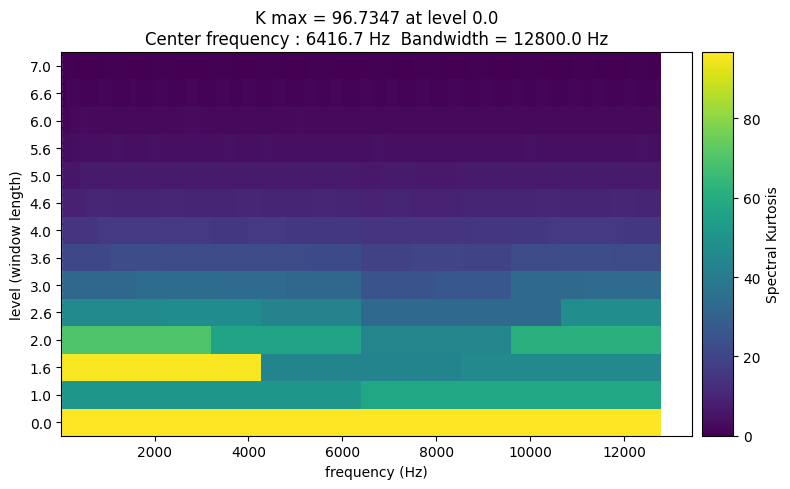

[   16.66666667 12799.        ]


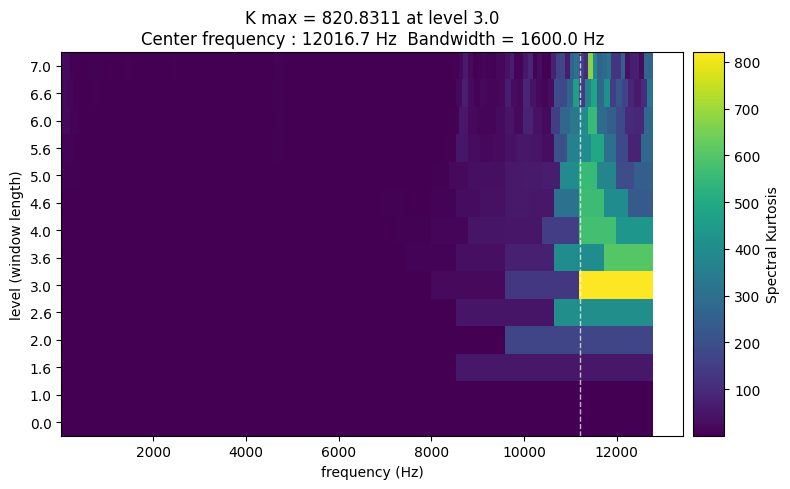

[11216.66666667 12799.        ]


In [28]:
# 1. 커토그램 계산 (nlevel 인자는 여기에 사용합니다)
kg.plot_kurtogram(Kwav_norm_107, Level_w_norm_107, maxK_norm_107, bw_norm_107, lvl_norm_107, fs, Wn_norm_107)
print(Wn_norm_107)
kg.plot_kurtogram(Kwav_fault_feature, Level_w_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, fs, Wn_fault_feature)
print(Wn_fault_feature)
kg.plot_kurtogram(Kwav_fault_signal_107, Level_w_fault_signal_107, maxK_fault_signal_107, bw_fault_signal_107, lvl_fault_signal_107, fs, Wn_fault_signal_107)
print(Wn_fault_signal_107)

In [29]:
filtered_signal = utils.filtering(x_fault_signal_0, fs, Wn_fault_signal, ftype= 'band')
# 힐버트 변환으로 엔벨로프를 추출합니다.
normal_analytic_signal = hilbert(x_normal[0])  # 저주파 대역에서 휠버트 변환 -> 고장의 주기를 파악 
normal_envelope = np.abs(normal_analytic_signal)
normal_envelope_no_dc = normal_envelope - np.mean(normal_envelope)



normal_fft_env = np.fft.fft(normal_envelope_no_dc)
normal_fft_freq = np.fft.fftfreq(len(normal_fft_env), 1/fs)
N = len(normal_fft_env) // 2

In [30]:
filtered_signal_100 = utils.filtering(x_fault_signal_100_0, fs, Wn_fault_signal_100, ftype= 'band')
# 힐버트 변환으로 엔벨로프를 추출합니다.
normal_analytic_signal_100 = hilbert(x_normal_100[0])  # 저주파 대역에서 휠버트 변환 -> 고장의 주기를 파악 
normal_envelope_100 = np.abs(normal_analytic_signal_100)
normal_envelope_no_dc_100 = normal_envelope_100 - np.mean(normal_envelope_100)



normal_fft_env_100 = np.fft.fft(normal_envelope_no_dc_100)
normal_fft_freq_100 = np.fft.fftfreq(len(normal_fft_env_100), 1/fs)
N = len(normal_fft_env_100) // 2

In [31]:
filtered_signal_107 = utils.filtering(x_fault_signal_107_0, fs, Wn_fault_signal_107, ftype= 'band')
# 힐버트 변환으로 엔벨로프를 추출합니다.
normal_analytic_signal_107 = hilbert(x_normal_107[0])  # 저주파 대역에서 휠버트 변환 -> 고장의 주기를 파악 
normal_envelope_107 = np.abs(normal_analytic_signal_107)
normal_envelope_no_dc_107 = normal_envelope_107 - np.mean(normal_envelope_107)



normal_fft_env_107 = np.fft.fft(normal_envelope_no_dc_107)
normal_fft_freq_107 = np.fft.fftfreq(len(normal_fft_env_107), 1/fs)
N = len(normal_fft_env_107) // 2

## Log.mat 0채널 FFT

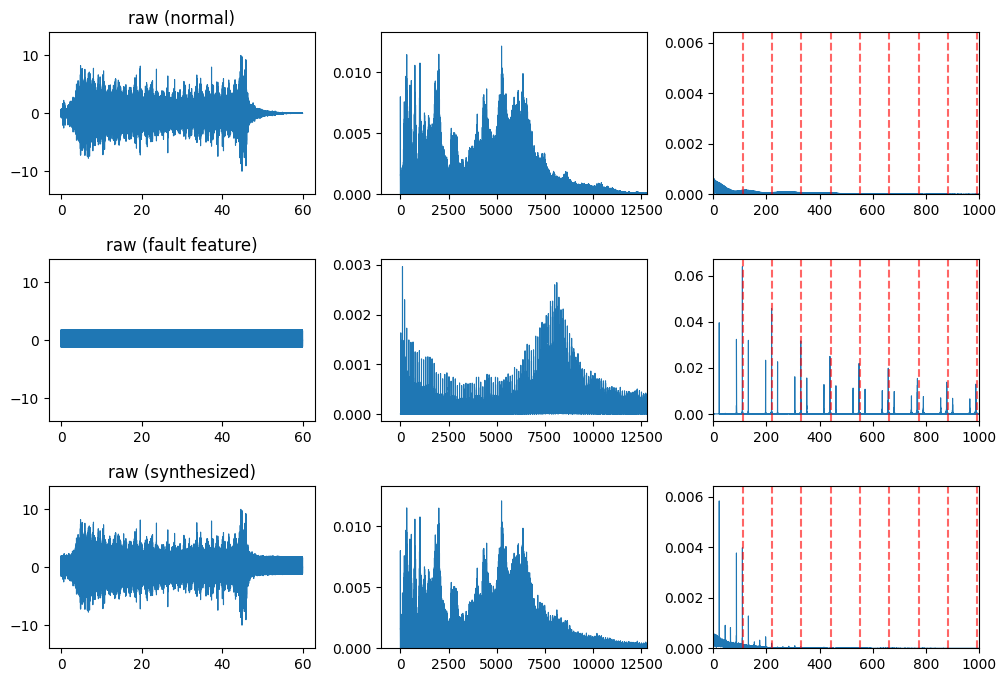

In [34]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal_0)
plot_raw(axs[0], t, cleaned_signal_0_0, 'raw (normal)'); axs[0].set_ylim([-1.4*ymax, 1.4*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)'); axs[3].set_ylim([-1.4*ymax, 1.4*ymax])
plot_raw(axs[6], t, x_fault_signal_0, 'raw (synthesized)'); axs[6].set_ylim([-1.4*ymax, 1.4*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal_0-np.mean(x_fault_signal_0), fs)[1])

plot_spectrum(axs[1], cleaned_signal_0_0, fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal_0, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
ymax = 1.1*np.max(fft_simple(env_s-np.mean(env_s), fs)[1])

plot_spectrum(axs[2], env_n, fs, 'env spectrum (normal, BP)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], env_f, fs, 'env spectrum (fault feature, BP)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], env_s, fs, 'env spectrum (synth, BP)', harmonic_lines, xlim=xlim, ylim=ymax)

# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()

## Log100.mat 0채널 FFT

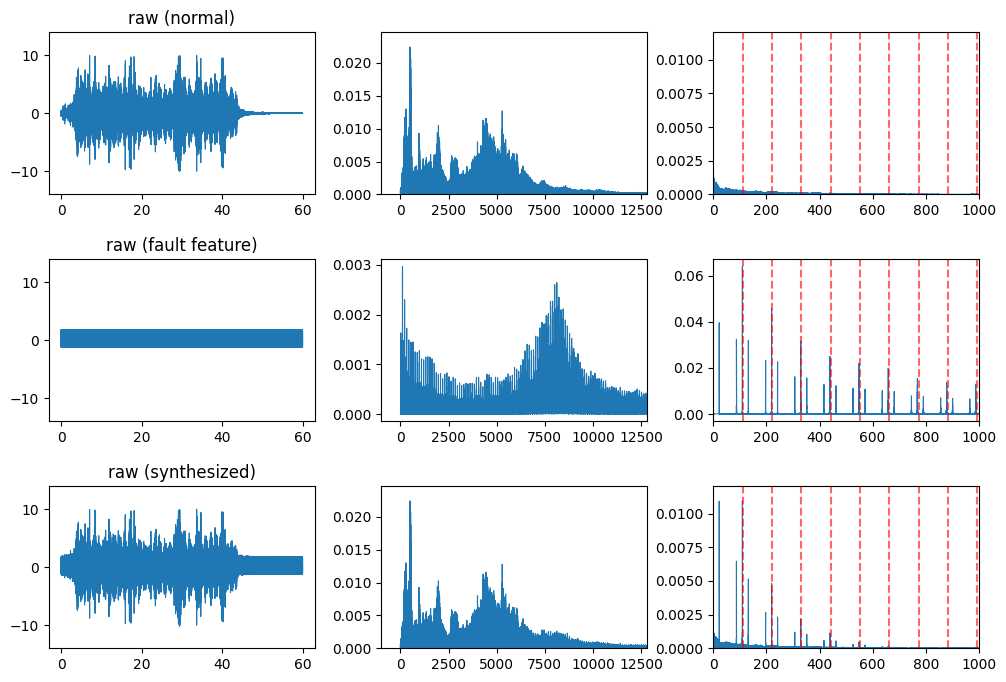

In [33]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal_100_0)
plot_raw(axs[0], t, cleaned_signal_100_0, 'raw (normal)'); axs[0].set_ylim([-1.4*ymax, 1.4*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)'); axs[3].set_ylim([-1.4*ymax, 1.4*ymax])
plot_raw(axs[6], t, x_fault_signal_100_0, 'raw (synthesized)'); axs[6].set_ylim([-1.4*ymax, 1.4*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal_100_0-np.mean(x_fault_signal_100_0), fs)[1])

plot_spectrum(axs[1], cleaned_signal_100_0, fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal_100_0, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
ymax = 1.1*np.max(fft_simple(env_s_100-np.mean(env_s_100), fs)[1])

plot_spectrum(axs[2], env_n_100, fs, 'env spectrum (normal, BP)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], env_f, fs, 'env spectrum (fault feature, BP)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], env_s_100, fs, 'env spectrum (synth, BP)', harmonic_lines, xlim=xlim, ylim=ymax)

# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()

## Log107.mat 0채널 FFT

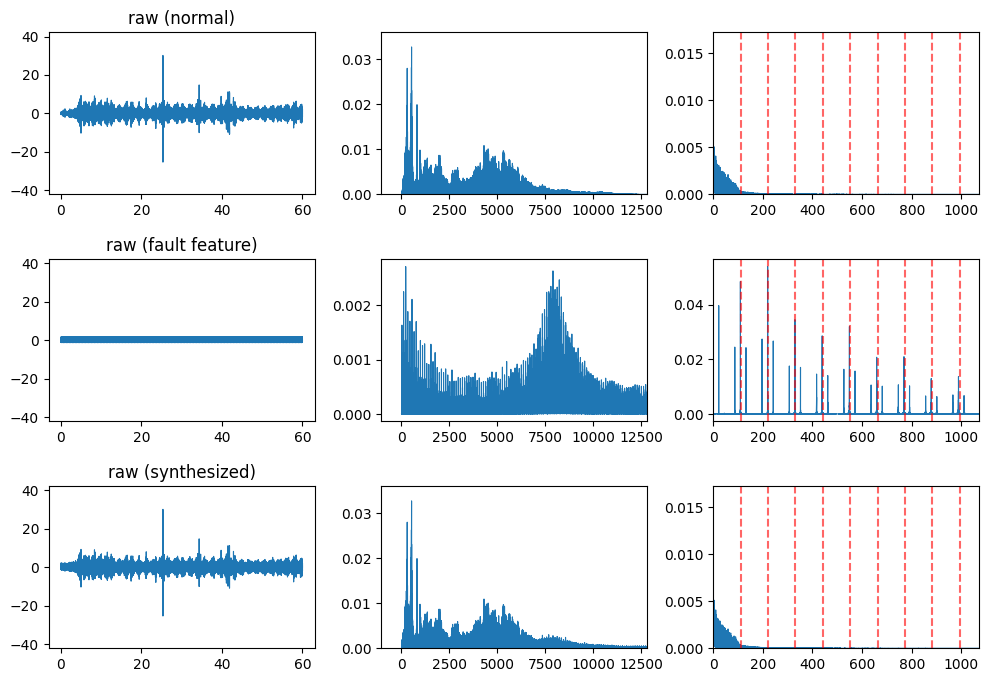

In [28]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal_107_0)
plot_raw(axs[0], t, x_normal_107[0], 'raw (normal)'); axs[0].set_ylim([-1.4*ymax, 1.4*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)'); axs[3].set_ylim([-1.4*ymax, 1.4*ymax])
plot_raw(axs[6], t, x_fault_signal_107_0, 'raw (synthesized)'); axs[6].set_ylim([-1.4*ymax, 1.4*ymax])

xlim = [-1070, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal_107_0-np.mean(x_fault_signal_107_0), fs)[1])

plot_spectrum(axs[1], x_normal_107[0], fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal_107_0, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1070]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1070]
ymax = 1.1*np.max(fft_simple(env_s_107-np.mean(env_s_107), fs)[1])

plot_spectrum(axs[2], env_n_107, fs, 'env spectrum (normal, BP)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], env_f, fs, 'env spectrum (fault feature, BP)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], env_s_107, fs, 'env spectrum (synth, BP)', harmonic_lines, xlim=xlim, ylim=ymax)

# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()